# StraitFlux examples

This notebook demonstrates the main StraitFlux workflows for native-grid ocean section diagnostics:

- line-integrated transports: volume, heat, salt, ice, and generic tracers
- cross-sections using the vector-projection method
- overturning diagnostics in depth and density space
- heat transport decomposition into overturning and gyre components
- optional barotropic adjustment
- water-mass transport decomposition
- workflows with file paths and already-open `xarray.Dataset` objects
- calculations for pre-defined sections (see indices.py) and for custom sections

The notebook is written as a template. Replace the example paths and model names with your own data files.


## 0. Installation and imports

Install StraitFlux from PyPI or from a local clone. If `xesmf` fails because `ESMFMKFILE` is missing, set the environment variable before importing `xesmf`.


In [ ]:
# Optional, only if xesmf/esmpy needs it on your system:
# %env ESMFMKFILE=/path/to/esmf.mk

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import xarray as xa
import matplotlib.pyplot as plt
from StraitFlux import masterscript_line as line
from StraitFlux import masterscript_cross as cross


## 1. Define model, section, files, and paths

StraitFlux can use predefined straits or user-defined sections. For most workflows you need velocity, temperature, vertical thickness, and optionally salinity, sea-ice, tracer, and mesh metrics.


In [ ]:
# --- User settings ---------------------------------------------------------
model = "CGLORSv8"
strait = "Fram"          # e.g. "Fram", "GSR", "Bering", "OSNAP", ...
time_start = "1993-01"
time_end   = "1993-12"

path_save = ""
path_indices = ""
path_mesh = ""

# --- path to files ------------------------------------------------------
path_f = "/srvfs/scratch/swinkelbauer/CGLORS-v8/"
file_u = "/srvfs/scratch/swinkelbauer/CGLORS-v8/NEMO_1m_1993*_grid_U_fixed.nc"
file_v = "/srvfs/scratch/swinkelbauer/CGLORS-v8/NEMO_1m_1993*_grid_V_fixed.nc"
file_t = "/srvfs/scratch/swinkelbauer/CGLORS-v8/NEMO_1m_1993*_grid_T_subset_fixed.nc"
file_s = "/srvfs/scratch/swinkelbauer/CGLORS-v8/NEMO_1m_1993*_grid_T_subset_fixed.nc"

# Vertical thicknesses.
# If only file_z is supplied, StraitFlux can estimate U/V face thicknesses from T-cell thickness.
file_z  = "/srvfs/scratch/swinkelbauer/CGLORS-v8/e3t_2.nc"
file_zu = "/srvfs/scratch/swinkelbauer/CGLORS-v8/e3u_2.nc"   # optional but preferred if available
file_zv = "/srvfs/scratch/swinkelbauer/CGLORS-v8/e3v_2.nc"   # optional but preferred if available

# Optional horizontal metrics.
# If not supplied, StraitFlux calculates and caches mesh_dyu_MODEL.nc and mesh_dxv_MODEL.nc.
mm = xa.open_dataset('/srvfs/scratch/swinkelbauer/CGLORS-v8/mesh_mask.nc')
from preprocessing import wrapper #StraitFlux.preprocessing
mesh_dxv = wrapper(mm).dxv[0]       #use the wrapper to get same structure as StraitFlux expects
mesh_dyu = wrapper(mm).dyu[0]       #use the wrapper to get same structure as StraitFlux expects


### Optional: user-defined variable names

If your files use variable names that are not already known to StraitFlux, provide a rename dictionary. User-supplied names are tried before the defaults.


In [4]:
user_rename_dict = {
    # Examples only; adapt to your files.
    # "uo": ["u", "vozocrtx"],
    # "vo": ["v", "vomecrty"],
    # "thetao": ["temp", "votemper"],
    # "so": ["salt", "vosaline"],
    # "thkcello": ["e3t", "e3t_0"],
}


## 2. Basic line-integrated transports

The function `line.transports()` integrates transports directly on the native model grid using the StraitFlux line-integration method.

The most common `product` options are:

- `"volume"`
- `"heat"`
- `"salt"`
- `"ice"`


In [12]:
volume = line.transports(
    "volume",
    strait,
    model,
    time_start,
    time_end,
    file_u,
    file_v,
    file_t,
    file_z,
    file_zu=file_zu,
    file_zv=file_zv,
    mesh_dxv=mesh_dxv,
    mesh_dyu=mesh_dyu,
    path_save=path_save,
    path_indices=path_indices,
    path_mesh=path_mesh,
    user_rename_dict=user_rename_dict,
)

volume

read t, u and v fields
load t, u and v fields
[########################################] | 100% Completed | 1.02 sms
[########################################] | 100% Completed | 1.18 sms
[########################################] | 100% Completed | 1.01 sms
[########################################] | 100% Completed | 2.01 sms
 ...calculating transport
calc u
calc v
calc line


<xarray.Dataset> Size: 288B
Dimensions:       (time: 12)
Coordinates:
  * time          (time) datetime64[ns] 96B 1993-01-15T17:25:09.677419008 ......
    time_instant  (time) datetime64[ns] 96B 1993-01-17 ... 1993-12-17
Data variables:
    CGLORSv8      (time) float64 96B -3.634e+06 -4.384e+06 ... -2.368e+06

In [13]:
heat = line.transports(
    "heat",
    strait,
    model,
    time_start,
    time_end,
    file_u,
    file_v,
    file_t,
    file_z,
    file_zu=file_zu,
    file_zv=file_zv,
    mesh_dxv=mesh_dxv,
    mesh_dyu=mesh_dyu,
    rho=1026.0,
    cp=3996.0,
    Tref=0.0,
    path_save=path_save,
    path_indices=path_indices,
    path_mesh=path_mesh,
    user_rename_dict=user_rename_dict,
)

heat


read t, u and v fields
load t, u and v fields
[########################################] | 100% Completed | 917.70 ms
[########################################] | 100% Completed | 914.97 ms
[########################################] | 100% Completed | 814.82 ms
[########################################] | 100% Completed | 2.01 sms
 ...calculating transport
rolling T
calc u
calc v
calc line


<xarray.Dataset> Size: 288B
Dimensions:       (time: 12)
Coordinates:
  * time          (time) datetime64[ns] 96B 1993-01-15T17:25:09.677419008 ......
    time_instant  (time) datetime64[ns] 96B 1993-01-17 ... 1993-12-17
Data variables:
    CGLORSv8      (time) float64 96B 9.151e+13 6.408e+13 ... 5.854e+13 6.845e+13

In [14]:
salt = line.transports(
    "salt",
    strait,
    model,
    time_start,
    time_end,
    file_u,
    file_v,
    file_t,
    file_z,
    file_s=file_s,
    file_zu=file_zu,
    file_zv=file_zv,
    mesh_dxv=mesh_dxv,
    mesh_dyu=mesh_dyu,
    path_save=path_save,
    path_indices=path_indices,
    path_mesh=path_mesh,
    user_rename_dict=user_rename_dict,
)

salt


read t, u and v fields
load t, u and v fields
[########################################] | 100% Completed | 817.51 ms
[########################################] | 100% Completed | 1.01 sms
[########################################] | 100% Completed | 1.11 sms
[########################################] | 100% Completed | 201.57 ms
 ...calculating transport
rolling S
calc u
calc v
calc line


<xarray.Dataset> Size: 288B
Dimensions:       (time: 12)
Coordinates:
  * time          (time) datetime64[ns] 96B 1993-01-15T17:25:09.677419008 ......
    time_instant  (time) datetime64[ns] 96B 1993-01-17 ... 1993-12-17
Data variables:
    CGLORSv8      (time) float64 96B -1.255e+11 -1.523e+11 ... -8.159e+10

### Plot a transport time series


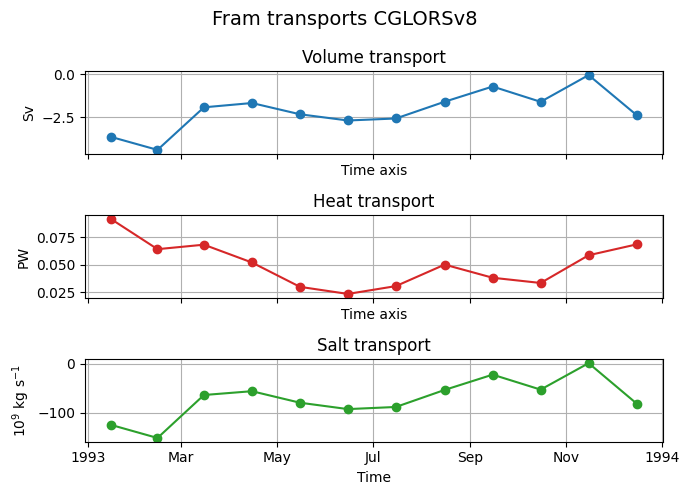

In [18]:
fig, ax = plt.subplots(3, 1, figsize=(7,5), sharex=True)

# Volume
(volume[model] / 1e6).plot(ax=ax[0], color="tab:blue", marker="o")
ax[0].set_ylabel("Sv")
ax[0].set_title("Volume transport")
ax[0].grid(True)

# Heat
(heat[model] / 1e15).plot(ax=ax[1], color="tab:red", marker="o")
ax[1].set_ylabel("PW")
ax[1].set_title("Heat transport")
ax[1].grid(True)

# Salt
(salt[model] / 1e9).plot(ax=ax[2], color="tab:green", marker="o")
ax[2].set_ylabel(r"$10^9$ kg s$^{-1}$")
ax[2].set_title("Salt transport")
ax[2].set_xlabel("Time")
ax[2].grid(True)

fig.suptitle(f"{strait} transports {model}", fontsize=14)

plt.tight_layout()
plt.show()


## 3. Generic tracer transports

`product="tracer"` can be used for any scalar tracer: DIC, oxygen, nitrate, phosphate, passive tracers, age tracers, etc.

The output units are approximately: $[\mathrm{tracer}] \times \mathrm{m^3\ s^{-1}}$

In [ ]:
'''
file_tracer = "/path/to/dissic_1993*.nc"

tracer_transport = line.transports(
    "tracer",
    strait,
    model,
    time_start,
    time_end,
    file_u,
    file_v,
    file_t,
    file_z,
    file_zu=file_zu,
    file_zv=file_zv,
    file_tracer=file_tracer,
    tracer_var="dissic",          # variable name after preprocessing
    tracer_units="mol m-3",       # optional metadata
    mesh_dxv=mesh_dxv,
    mesh_dyu=mesh_dyu,
    path_save=path_save,
    path_indices=path_indices,
    path_mesh=path_mesh,
    user_rename_dict=user_rename_dict,
)
'''


## 4. Sea-ice transports

For sea-ice transports, use sea-ice velocity files as `file_u` and `file_v`, and supply sea-ice concentration and thickness.


In [ ]:
'''
file_ui = "/path/to/seaice_u_1993*.nc"
file_vi = "/path/to/seaice_v_1993*.nc"
file_sic = "/path/to/siconc_1993*.nc"
file_sit = "/path/to/sithick_1993*.nc"

ice = line.transports(
    "ice",
    strait,
    model,
    time_start,
    time_end,
    file_ui,
    file_vi,
    file_t,       # not used for ice physics, but kept for function signature
    file_z,       # not used for ice physics
    file_sic=file_sic,
    file_sit=file_sit,
    mesh_dxv=mesh_dxv,
    mesh_dyu=mesh_dyu,
    path_save=path_save,
    path_indices=path_indices,
    path_mesh=path_mesh,
    user_rename_dict=user_rename_dict,
)
'''


## 5. Cross-sections with the vector-projection method

The cross-section functions use the vector-projection method. This is useful when you want the vertical structure of velocity, temperature, salinity, or transport across a section, not just one integrated number.


In [37]:
uv_cross = cross.vel_projection(
    strait,
    model,
    time_start,
    time_end,
    file_u,
    file_v,
    file_t,
    file_z,
    file_zu=file_zu,
    file_zv=file_zv,
    mesh_dxv=mesh_dxv,
    mesh_dyu=mesh_dyu,
    path_save=path_save,
    path_indices=path_indices,
    path_mesh=path_mesh,
)

read t, u and v fields
load t, u and v fields
[########################################] | 100% Completed | 614.04 ms
[########################################] | 100% Completed | 714.34 ms
[########################################] | 100% Completed | 919.76 ms
[########################################] | 100% Completed | 302.82 ms
calc dz at cell faces


100%|██████████| 56/56 [00:00<00:00, 4480.67it/s]

calculating regridder
0.080718994140625


0.19603681564331055
regridding
0.07562637329101562


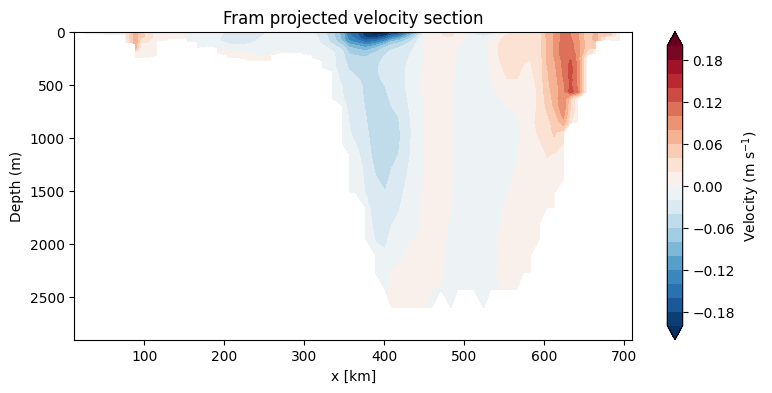

In [57]:
fig, ax = plt.subplots(figsize=(9, 4))
levels=np.arange(-0.2, 0.22, 0.02)
cf = plt.contourf(uv_cross.x/1e3, uv_cross.depth, uv_cross.uv.mean("time"), levels=levels,extend='both', cmap="RdBu_r")
cbar = plt.colorbar(cf, ax=ax)
cbar.set_label("Velocity (m s$^{-1}$)")
plt.ylim(2900,0)
ax.set_title(f"{strait} projected velocity section")
ax.set_xlabel("x [km]")
ax.set_ylabel("Depth (m)")
plt.show()


In [39]:
T_section = cross.TS_interp(
    "T",
    strait,
    model,
    time_start,
    time_end,
    file_u,
    file_t,
    path_save=path_save,
    path_indices=path_indices,
    path_mesh=path_mesh,
)

S_section = cross.TS_interp(
    "S",
    strait,
    model,
    time_start,
    time_end,
    file_u,
    file_t,
    file_s=file_s,
    path_save=path_save,
    path_indices=path_indices,
    path_mesh=path_mesh,
)


read t and/or s fields
[########################################] | 100% Completed | 613.27 ms
[########################################] | 100% Completed | 202.52 ms
calculating regridder


100%|██████████| 75/75 [00:02<00:00, 27.13it/s]


regridding
read t and/or s fields
[########################################] | 100% Completed | 713.67 ms
[########################################] | 100% Completed | 203.49 ms
calculating regridder


100%|██████████| 75/75 [00:02<00:00, 27.28it/s]


regridding


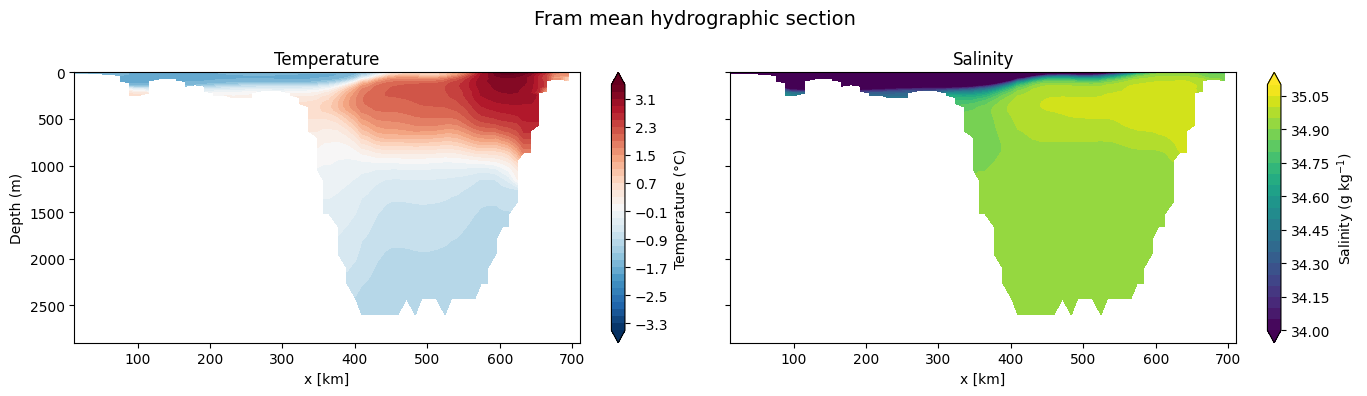

In [55]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

# Temperature
levelsT = np.arange(-3.5, 3.6, 0.2)
cf1 = ax[0].contourf(
    T_section.T.mean("time").x/1e3,
    T_section.T.mean("time").depth,
    T_section.T.mean("time"),
    levels=levelsT,
    extend="both",
    cmap="RdBu_r",
)
cbar1 = plt.colorbar(cf1, ax=ax[0])
cbar1.set_label("Temperature (°C)")
ax[0].set_ylim(2900, 0)
ax[0].set_title("Temperature")
ax[0].set_ylabel("Depth (m)")
ax[0].set_xlabel("x [km]")

# Salinity
levelsS = np.arange(34, 35.1, 0.05)
cf2 = ax[1].contourf(
    S_section.S.mean("time").x/1e3,
    S_section.S.mean("time").depth,
    S_section.S.mean("time"),
    levels=levelsS,
    extend="both",
    cmap="viridis",
)
cbar2 = plt.colorbar(cf2, ax=ax[1])
cbar2.set_label("Salinity (g kg$^{-1}$)")
ax[1].set_ylim(2900, 0)
ax[1].set_title("Salinity")
ax[1].set_xlabel("x [km]")

fig.suptitle(f"{strait} mean hydrographic section", fontsize=14)

plt.tight_layout()
plt.show()

### comparison between the line integration and vector projection methods:

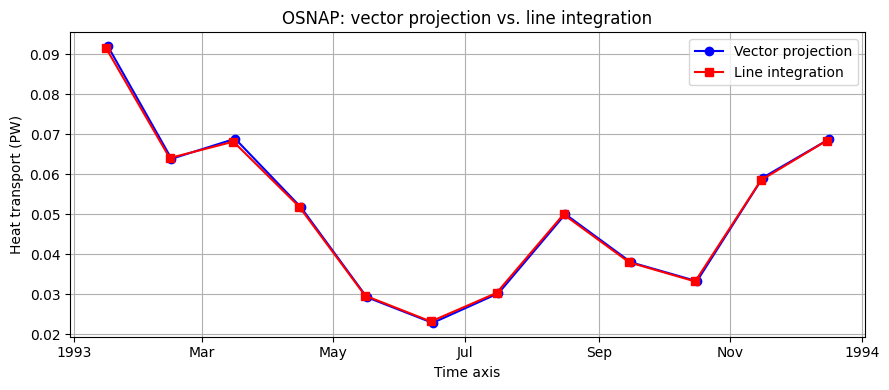

In [ ]:
# Heat transport from vector projection method
heat_vp = (
    uv_cross.uv
    * uv_cross.dx_int
    * uv_cross.dz_int
    * T_section.T.values
    * 1023
    * 3996
).sum(dim=("depth", "x")) / 1e15

# Heat transport from line integration method
heat_line = heat[model] / 1e15

fig, ax = plt.subplots(figsize=(9, 4))

heat_vp.plot(
    ax=ax,
    marker="o", c='b',
    label="Vector projection",
)

heat_line.plot(
    ax=ax,
    marker="s", c='r',
    label="Line integration",
)

ax.set_ylabel("Heat transport (PW)")
ax.set_title(f"{strait}: vector projection vs. line integration")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

The line-integration and vector-projection methods yield nearly identical transport estimates, demonstrating that the vector-projection approach provides an accurate approximation of the native-grid calculation. Small differences arise because the line-integration method follows the native model grid exactly, whereas the vector-projection method projects velocities onto an idealized section. For quantitative transport calculations, the line-integration method is therefore recommended whenever possible. The vector-projection method is particularly useful for visualizing velocity fields and constructing continuous cross-sections.

## 6. Overturning diagnostics and heat-transport decomposition

`transports_overturning()` returns line-integrated transport diagnostics plus overturning streamfunctions.

Without salinity, the function returns depth-space diagnostics. With salinity, it also returns density-space diagnostics.


In [66]:
strait='OSNAP'
ov = line.transports_overturning(
    strait,
    model,
    time_start,
    time_end,
    file_u,
    file_v,
    file_t,
    file_z,
    file_s=file_s,          # supply salinity to enable density-space MOC
    file_zu=file_zu,
    file_zv=file_zv,
    mesh_dxv=mesh_dxv,
    mesh_dyu=mesh_dyu,
    path_save=path_save,
    path_indices=path_indices,
    path_mesh=path_mesh,
    sigmin=23.0,            # minimum density for overturning calculation
    sigstp=0.02,            # density bin width for overturning calculation
    nbins=270,              # number of density bins for overturning calculation
    user_rename_dict=user_rename_dict,
    return_diagnostics=False,
)


read and load surface fields for indices/grid check
[########################################] | 100% Completed | 203.93 ms
[########################################] | 100% Completed | 203.59 ms
[########################################] | 100% Completed | 203.48 ms
read t, u, v and optional s fields
load final section subset
[########################################] | 100% Completed | 1.12 sms
[########################################] | 100% Completed | 1.13 sms
[########################################] | 100% Completed | 1.40 sms
[########################################] | 100% Completed | 1.81 sms
[########################################] | 100% Completed | 1.12 sms
[########################################] | 100% Completed | 1.81 ss
[########################################] | 100% Completed | 805.41 ms


In [67]:
# Common output variables
list(ov.data_vars)

['volume_transport_Sv',
 'overturning_depth_layer_Sv',
 'overturning_depth_streamfunction_Sv',
 'MOC_depth_Sv',
 'heat_total_PW',
 'heat_overturning_depth_PW',
 'heat_gyre_depth_PW',
 'salt_total',
 'salt_overturning_depth',
 'salt_gyre_depth',
 'overturning_density_bin_Sv',
 'overturning_density_streamfunction_Sv',
 'MOC_density_Sv',
 'heat_overturning_density_PW',
 'heat_gyre_density_PW',
 'salt_overturning_density',
 'salt_gyre_density']

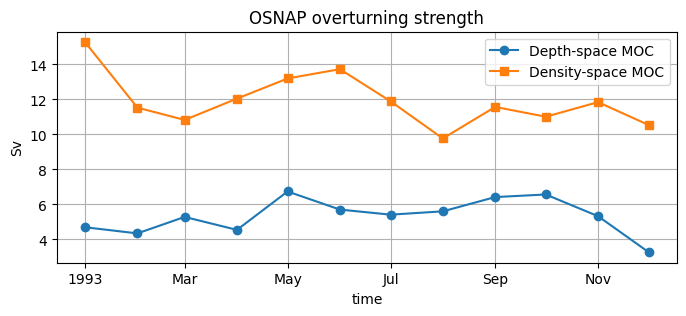

In [68]:
fig, ax = plt.subplots(figsize=(8, 3))
ov["MOC_depth_Sv"].plot(ax=ax, marker="o", label="Depth-space MOC")
if "MOC_density_Sv" in ov:
    ov["MOC_density_Sv"].plot(ax=ax, marker="s", label="Density-space MOC")
ax.set_title(f"{strait} overturning strength")
ax.set_ylabel("Sv")
ax.grid(True)
ax.legend()
plt.show()


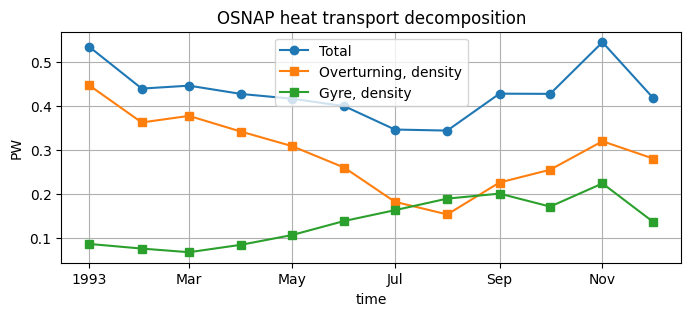

In [70]:
fig, ax = plt.subplots(figsize=(8, 3))
ov["heat_total_PW"].plot(ax=ax, marker="o", label="Total")
if "heat_overturning_density_PW" in ov:
    ov["heat_overturning_density_PW"].plot(ax=ax, marker="s", label="Overturning, density")
    ov["heat_gyre_density_PW"].plot(ax=ax, marker="s", label="Gyre, density")
ax.set_title(f"{strait} heat transport decomposition")
ax.set_ylabel("PW")
ax.grid(True)
ax.legend()
plt.show()


In [72]:
ov

<xarray.Dataset> Size: 70kB
Dimensions:                                (time: 12, lev: 75, density_bin: 270)
Coordinates:
  * time                                   (time) datetime64[ns] 96B 1993-01-...
  * lev                                    (lev) float32 300B 0.5058 ... 5.90...
  * density_bin                            (density_bin) float64 2kB 23.01 .....
Data variables: (12/17)
    volume_transport_Sv                    (time) float64 96B -0.6297 ... -0....
    overturning_depth_layer_Sv             (time, lev) float64 7kB -0.02697 ....
    overturning_depth_streamfunction_Sv    (time, lev) float64 7kB -0.02697 ....
    MOC_depth_Sv                           (time) float64 96B 4.696 ... 3.269
    heat_total_PW                          (time) float64 96B 0.5333 ... 0.4179
    heat_overturning_depth_PW              (time) float64 96B 0.03187 ... 0.0...
    ...                                     ...
    overturning_density_streamfunction_Sv  (time, density_bin) float64 26kB 0...
    MOC_density_Sv                         (time) float64 96B 15.27 ... 10.54
    heat_overturning_density_PW            (time) float64 96B 0.4461 ... 0.2806
    heat_gyre_density_PW                   (time) float64 96B 0.08719 ... 0.1373
    salt_overturning_density               (time) float64 96B -8.159e+09 ... ...
    salt_gyre_density                      (time) float64 96B 2.771e+09 ... 4...
Attributes:
    barotropic_correction_applied:  False
    density_space_computed:         True
    section_lon_for_gsw:            -56.64018249511719
    section_lat_for_gsw:            52.17859649658203
    method:                         StraitFlux zig-zag line indices with exte...

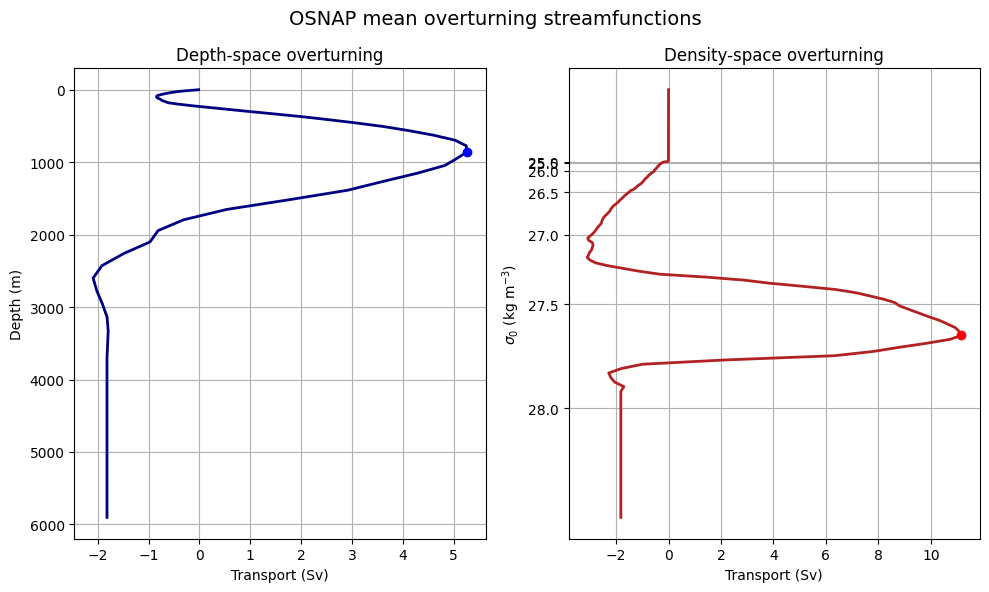

In [83]:
fig, ax = plt.subplots(1, 2, figsize=(10, 6), sharex=False)

# --------------------------------------------------
# Depth-space
# --------------------------------------------------
psi_z = ov["overturning_depth_streamfunction_Sv"].mean("time")
imax = psi_z.argmax()


ax[0].plot(psi_z, psi_z.lev, color="navy", lw=2)
ax[0].scatter(
    psi_z.isel(lev=imax),
    psi_z.lev.isel(lev=imax),
    color="b",
    zorder=5,
)
ax[0].invert_yaxis()
ax[0].set_xlabel("Transport (Sv)")
ax[0].set_ylabel("Depth (m)")
ax[0].set_title("Depth-space overturning")
ax[0].grid(True)

# --------------------------------------------------
# Density-space
# --------------------------------------------------
psi_rho = ov["overturning_density_streamfunction_Sv"].mean("time")

def transform_sigma(sigma):
    return (sigma - 25.0) ** 3

imax = psi_rho.argmax()

ax[1].plot(psi_rho, transform_sigma(psi_rho.density_bin),c='firebrick', lw=2)
ax[1].scatter(
    psi_rho.isel(density_bin=imax),
    transform_sigma(psi_rho.density_bin.isel(density_bin=imax)),
    color="red",
    zorder=5,
)
ticks = np.arange(25, 28.5, 0.5)

ax[1].set_yticks(transform_sigma(ticks))
ax[1].set_yticklabels([f"{t:.1f}" for t in ticks])

ax[1].invert_yaxis()

ax[1].set_xlabel("Transport (Sv)")
ax[1].set_ylabel(r"$\sigma_0$ (kg m$^{-3}$)")
ax[1].set_title("Density-space overturning")
ax[1].grid(True)

fig.suptitle(f"{strait} mean overturning streamfunctions", fontsize=14)

plt.tight_layout()
plt.show()

## 7. Barotropic adjustment

Some workflows require the net volume transport through a section to match a prescribed target, for example zero net volume transport across a closed section. StraitFlux can apply a barotropic correction.


In [84]:
strait='OSNAP'
ov_bt = line.transports_overturning(
    strait,
    model,
    time_start,
    time_end,
    file_u,
    file_v,
    file_t,
    file_z,
    file_s=file_s,
    file_zu=file_zu,
    file_zv=file_zv,
    mesh_dxv=mesh_dxv,
    mesh_dyu=mesh_dyu,
    apply_barotropic_correction=True,   # whether to apply barotropic correction
    transport_target_m3s=0.0,           # target barotropic transport for correction
    path_save=path_save,
    path_indices=path_indices,
    path_mesh=path_mesh,
    user_rename_dict=user_rename_dict,
    return_diagnostics=True,
)

read and load surface fields for indices/grid check
[########################################] | 100% Completed | 204.85 ms
[########################################] | 100% Completed | 203.89 ms
[########################################] | 100% Completed | 203.38 ms
read t, u, v and optional s fields
load final section subset
[########################################] | 100% Completed | 1.02 sms
[########################################] | 100% Completed | 1.13 sms
[########################################] | 100% Completed | 1.13 sms
[########################################] | 100% Completed | 202.91 ms
[########################################] | 100% Completed | 1.13 sms
[########################################] | 100% Completed | 1.81 ss
[########################################] | 100% Completed | 1.81 sms


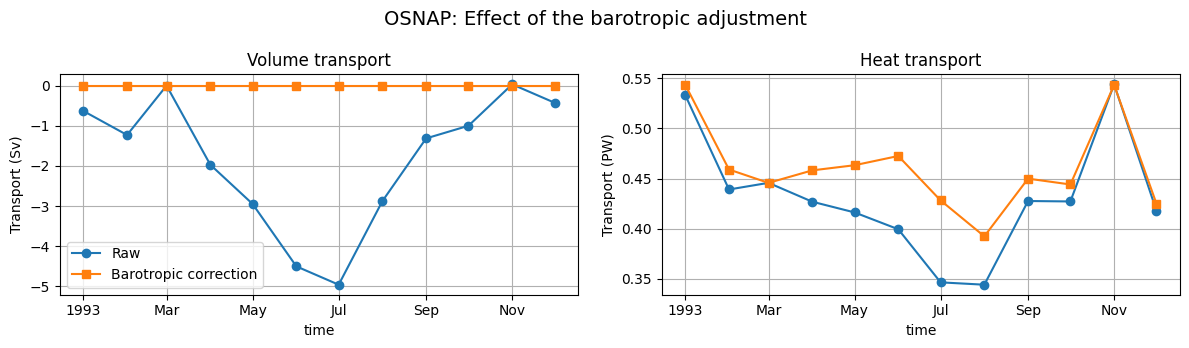

In [90]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5), sharex=True)

# --------------------------------------------------
# Volume transport
# --------------------------------------------------
ov["volume_transport_Sv"].plot(
    ax=ax[0],
    marker="o",
    label="Raw",
)

ov_bt["volume_transport_Sv"].plot(
    ax=ax[0],
    marker="s",
    label="Barotropic correction",
)

ax[0].set_title("Volume transport")
ax[0].set_ylabel("Transport (Sv)")
ax[0].grid(True)
ax[0].legend()

# --------------------------------------------------
# Heat transport
# --------------------------------------------------
ov["heat_total_PW"].plot(
    ax=ax[1],
    marker="o",
    label="Raw",
)

ov_bt["heat_total_PW"].plot(
    ax=ax[1],
    marker="s",
    label="Barotropic correction",
)

ax[1].set_title("Heat transport")
ax[1].set_ylabel("Transport (PW)")
ax[1].grid(True)

fig.suptitle(f"{strait}: Effect of the barotropic adjustment", fontsize=14)

plt.tight_layout()
plt.show()


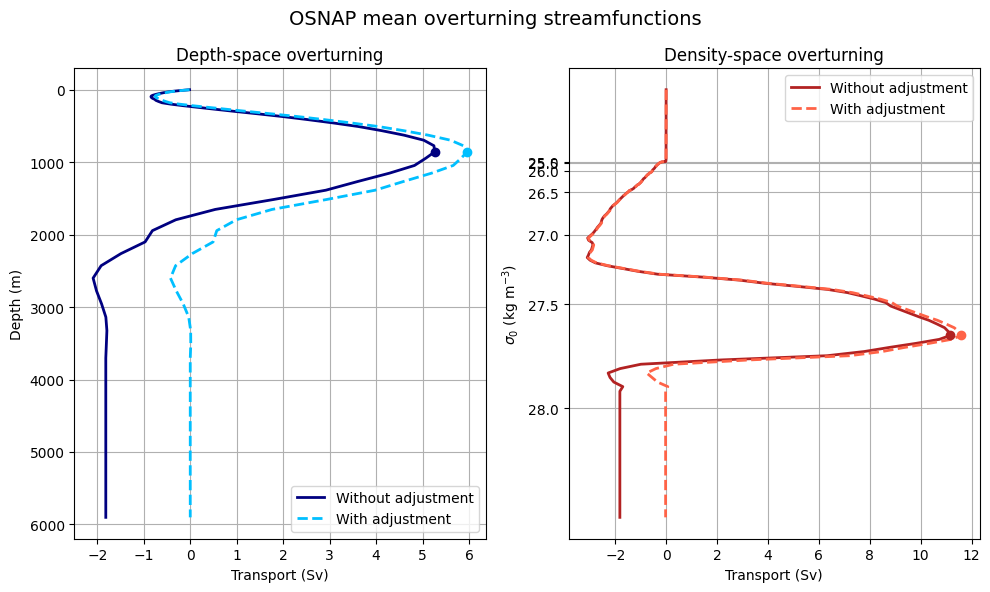

In [112]:
fig, ax = plt.subplots(1, 2, figsize=(10, 6), sharex=False)

# ==================================================
# Depth-space
# ==================================================
psi_z = ov["overturning_depth_streamfunction_Sv"].mean("time")
psi_z_bt = ov_bt["overturning_depth_streamfunction_Sv"].mean("time")

imax = psi_z.argmax()
imax_bt = psi_z_bt.argmax()

ax[0].plot(
    psi_z,
    psi_z.lev,
    color="navy",
    lw=2,
    label="Without adjustment",
)

ax[0].plot(
    psi_z_bt,
    psi_z_bt.lev,
    color="deepskyblue",
    lw=2,
    ls="--",
    label="With adjustment",
)

ax[0].scatter(
    psi_z.isel(lev=imax),
    psi_z.lev.isel(lev=imax),
    color="navy",
    zorder=5,
)

ax[0].scatter(
    psi_z_bt.isel(lev=imax_bt),
    psi_z_bt.lev.isel(lev=imax_bt),
    color="deepskyblue",
    zorder=5,
)

ax[0].invert_yaxis()
ax[0].set_xlabel("Transport (Sv)")
ax[0].set_ylabel("Depth (m)")
ax[0].set_title("Depth-space overturning")
ax[0].grid(True)
ax[0].legend()

# ==================================================
# Density-space
# ==================================================
psi_rho = ov["overturning_density_streamfunction_Sv"].mean("time")
psi_rho_bt = ov_bt["overturning_density_streamfunction_Sv"].mean("time")


def transform_sigma(sigma):
    return (sigma - 25.0) ** 3


imax = psi_rho.argmax()
imax_bt = psi_rho_bt.argmax()

ax[1].plot(
    psi_rho,
    transform_sigma(psi_rho.density_bin),
    color="firebrick",
    lw=2,
    label="Without adjustment",
)

ax[1].plot(
    psi_rho_bt,
    transform_sigma(psi_rho_bt.density_bin),
    color="tomato",
    lw=2,
    ls="--",
    label="With adjustment",
)

ax[1].scatter(
    psi_rho.isel(density_bin=imax),
    transform_sigma(psi_rho.density_bin.isel(density_bin=imax)),
    color="firebrick",
    zorder=5,
)

ax[1].scatter(
    psi_rho_bt.isel(density_bin=imax_bt),
    transform_sigma(psi_rho_bt.density_bin.isel(density_bin=imax_bt)),
    color="tomato",
    zorder=5,
)

ticks = np.arange(25, 28.5, 0.5)

ax[1].set_yticks(transform_sigma(ticks))
ax[1].set_yticklabels([f"{t:.1f}" for t in ticks])

ax[1].invert_yaxis()

ax[1].set_xlabel("Transport (Sv)")
ax[1].set_ylabel(r"$\sigma_0$ (kg m$^{-3}$)")
ax[1].set_title("Density-space overturning")
ax[1].grid(True)
ax[1].legend()
fig.suptitle(f"{strait} mean overturning streamfunctions", fontsize=14)

plt.tight_layout()
plt.show()

## 8. Water-mass transport decomposition

Water-mass definitions are region-specific. You can define water masses using simple thresholds in temperature, salinity, and density. The example below follows a Greenland–Scotland Ridge style classification.

See e.g. Mayer et al. (2023, https://doi.org/10.5194/sp-1-osr7-14-2023)


In [ ]:
#These thresholds are region-specific and should be adapted for other sections or scientific applications.

watermass_definitions = {
    "Overflow": {
        "sigma0_min": 27.8,
    },
    "Polar": {
        "thetao_max": 4.0,
        "sigma0_max": 27.7,
    },
    "Atlantic": {
        "thetao_min": 4.0,
        "sigma0_max": 27.8,
    },
}


In [93]:
strait='GSR'
wm = line.watermass_transports(
    strait,
    model,
    time_start,
    time_end,
    file_u,
    file_v,
    file_t,
    file_s,
    file_z,
    file_zu=file_zu,
    file_zv=file_zv,
    mesh_dxv=mesh_dxv,
    mesh_dyu=mesh_dyu,
    watermass_definitions=watermass_definitions,
    path_save=path_save,
    path_indices=path_indices,
    path_mesh=path_mesh,
    user_rename_dict=user_rename_dict,
    return_diagnostics=False,
)


read and load surface fields for indices/grid check
[########################################] | 100% Completed | 204.97 ms
[########################################] | 100% Completed | 203.76 ms
[########################################] | 100% Completed | 203.30 ms
calc indices
calculating indices...
0.1
line good
line good
read t, s, u, v and z fields
load final section subset
[########################################] | 100% Completed | 613.52 ms
[########################################] | 100% Completed | 613.39 ms
[########################################] | 100% Completed | 717.78 ms
[########################################] | 100% Completed | 896.42 ms
[########################################] | 100% Completed | 202.53 ms
[########################################] | 100% Completed | 1.71 sms
[########################################] | 100% Completed | 1.81 sms


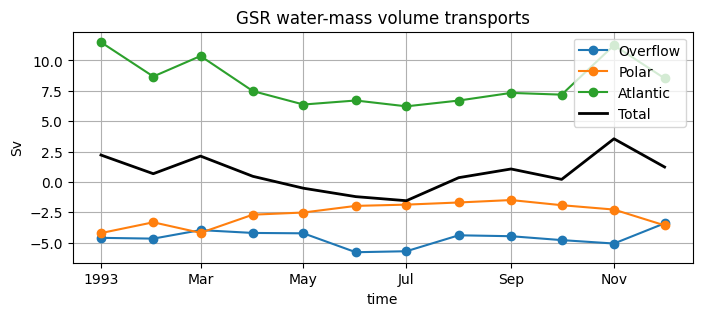

In [94]:
fig, ax = plt.subplots(figsize=(8, 3))
for name in watermass_definitions:
    var = f"volume_transport_{name}_Sv"
    if var in wm:
        wm[var].plot(ax=ax, marker="o", label=name)
wm["volume_transport_Total_Sv"].plot(ax=ax, color="k", linewidth=2, label="Total")
ax.set_ylabel("Sv")
ax.set_title(f"{strait} water-mass volume transports")
ax.grid(True)
ax.legend()
plt.show()


## 9. Using already-open xarray datasets

The dataset-based functions are useful for Pangeo, Intake, Zarr, or any workflow where the data are already opened and not stored as local NetCDF file paths.


In [95]:
ds_u = xa.open_mfdataset(file_u, chunks={"time": 1})
ds_v = xa.open_mfdataset(file_v, chunks={"time": 1})
ds_t = xa.open_mfdataset(file_t, chunks={"time": 1})
ds_s = xa.open_mfdataset(file_s, chunks={"time": 1})
ds_z = xa.open_mfdataset(file_z, chunks={"time": 1})
ds_zu = xa.open_mfdataset(file_zu, chunks={"time": 1}) if file_zu else None
ds_zv = xa.open_mfdataset(file_zv, chunks={"time": 1}) if file_zv else None


In [97]:
strait='OSNAP'
ov_ds = line.transports_overturning_ds(
    strait,
    model,
    time_start,
    time_end,
    ds_u,
    ds_v,
    ds_t,
    ds_z,
    ds_s=ds_s,
    ds_zu=ds_zu,
    ds_zv=ds_zv,
    mesh_dxv=mesh_dxv,
    mesh_dyu=mesh_dyu,
    path_save=path_save,
    path_indices=path_indices,
    path_mesh=path_mesh,
    user_rename_dict=user_rename_dict,
)

prepare surface fields for indices/grid check
[########################################] | 100% Completed | 1.12 sms
[########################################] | 100% Completed | 1.12 sms
[########################################] | 100% Completed | 1.12 sms
prepare and subset t, u, v, z and optional s fields
load final section subset
[########################################] | 100% Completed | 1.02 sms
[########################################] | 100% Completed | 1.02 sms
[########################################] | 100% Completed | 1.12 sms
[########################################] | 100% Completed | 202.52 ms
[########################################] | 100% Completed | 1.02 sms
[########################################] | 100% Completed | 202.66 ms
[########################################] | 100% Completed | 1.81 sms


In [99]:
heat2 = line.transports(
    "heat",
    strait,
    model,
    time_start,
    time_end,
    file_u,
    file_v,
    file_t,
    file_z,
    file_zu=file_zu,
    file_zv=file_zv,
    mesh_dxv=mesh_dxv,
    mesh_dyu=mesh_dyu,
    rho=1026.0,
    cp=3996.0,
    Tref=0.0,
    path_save=path_save,
    path_indices=path_indices,
    path_mesh=path_mesh,
    user_rename_dict=user_rename_dict,
)

read t, u and v fields
load t, u and v fields
[########################################] | 100% Completed | 1.02 sms
[########################################] | 100% Completed | 1.02 sms
[########################################] | 100% Completed | 1.12 sms
[########################################] | 100% Completed | 1.81 sms
 ...calculating transport
rolling T
calc u
calc v
calc line


## 10. Custom sections

If a section is not predefined, provide either start/end coordinates via `coords`, or a full polyline via `set_latlon=True`, `lon_p=...`, and `lat_p=...`.

This allows transports to be calculated across arbitrary sections, including exactly along observational mooring arrays (e.g. OSNAP, RAPID, or SAMBA), repeat hydrographic sections, or user-defined transects.

In [116]:
# Example: define a simple start/end section
custom_coords = (52, -57, 48.5, -3.5)  # (lat_start, lon_start, lat_end, lon_end)

custom_transport = line.transports(
    "volume",
    "MyCustomSection",
    model,
    time_start,
    time_end,
    file_u,
    file_v,
    file_t,
    file_z,
    file_zu=file_zu,
    file_zv=file_zv,
    coords=custom_coords,
    mesh_dxv=mesh_dxv,
    mesh_dyu=mesh_dyu,
    path_save=path_save,
    path_indices=path_indices,
    path_mesh=path_mesh,
    user_rename_dict=user_rename_dict,
)


calc indices
read and load files for indices
[########################################] | 100% Completed | 545.95 ms
[########################################] | 100% Completed | 203.40 ms
[########################################] | 100% Completed | 203.68 ms
calculating indices...
0.1
line good
line good
read t, u and v fields
load t, u and v fields
[########################################] | 100% Completed | 613.64 ms
[########################################] | 100% Completed | 614.35 ms
[########################################] | 100% Completed | 615.34 ms
[########################################] | 100% Completed | 1.81 ss
 ...calculating transport
calc u
calc v
calc line


In [122]:
oc=xa.open_dataset('/mnt/users/staff/swinkelbauer/PhD/calculations/CMIP/Plots/Test/osnap_coords_4.nc')

In [123]:
# Example: define a polyline section
lon_p = oc.lon
lat_p = oc.lat

polyline_transport = line.transports(
    "volume",
    "OSNAP_exact",
    model,
    time_start,
    time_end,
    file_u,
    file_v,
    file_t,
    file_z,
    file_zu=file_zu,
    file_zv=file_zv,
    set_latlon=True,
    lon_p=lon_p,
    lat_p=lat_p,
    mesh_dxv=mesh_dxv,
    mesh_dyu=mesh_dyu,
    path_save=path_save,
    path_indices=path_indices,
    path_mesh=path_mesh,
    user_rename_dict=user_rename_dict,
)


calc indices
read and load files for indices
[########################################] | 100% Completed | 203.96 ms
[########################################] | 100% Completed | 203.35 ms
[########################################] | 100% Completed | 203.49 ms
calculating indices...
0.1
!!!ATTENTION!!!: last point water, recheck indices line!
line good
read t, u and v fields
load t, u and v fields
[########################################] | 100% Completed | 1.02 sms
[########################################] | 100% Completed | 1.03 sms
[########################################] | 100% Completed | 1.12 sms
[########################################] | 100% Completed | 12.18 ss
 ...calculating transport
calc u
calc v
calc line


#### Visualization of the OSNAP section on the native model grid using exact coordinates vs approximated ones

In [124]:
indices_osnap_exact=xa.open_dataset('/srvfs/home/swinkelbauer/PhD/calculations/Ocean/MER-EP/TEST/CGLORSv8_OSNAP_exact_indices.nc')
indices_osnap_predef=xa.open_dataset('/srvfs/home/swinkelbauer/PhD/calculations/Ocean/MER-EP/TEST/CGLORSv8_OSNAP_indices.nc')

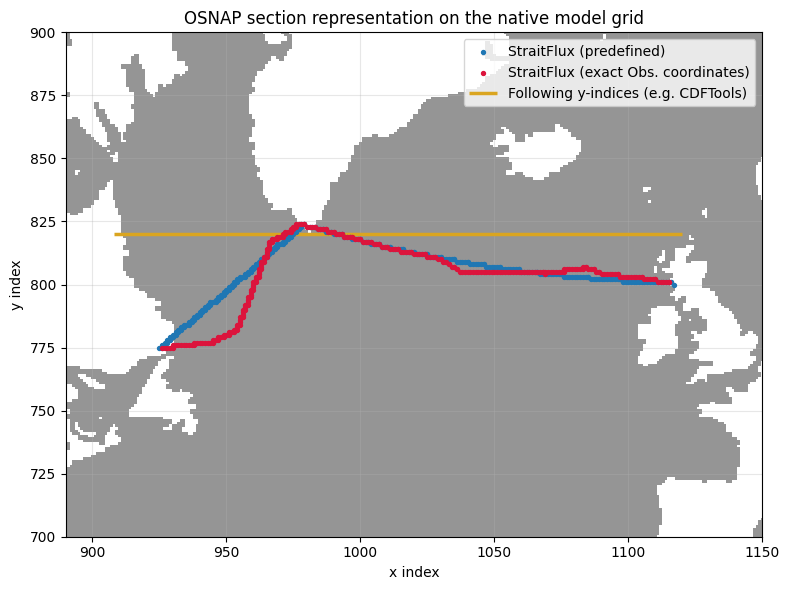

In [149]:
t=ds_t.thetao[0,0].load()
m=t/t
fig, ax = plt.subplots(figsize=(8, 6))

# background
(m).plot(
    ax=ax,
    cmap="Greys",
    add_colorbar=False,
)

# StraitFlux predefined section
ax.scatter(
    indices_osnap_predef.indices[:,0],
    indices_osnap_predef.indices[:,1],
    s=8,
    c="tab:blue",
    label="StraitFlux (predefined)",
    zorder=3,
)
ax.scatter(
    indices_osnap_predef.indices[:,2],
    indices_osnap_predef.indices[:,3],
    s=8,
    c="tab:blue",
    zorder=3,
)

# StraitFlux exact section
ax.scatter(
    indices_osnap_exact.indices[:,0],
    indices_osnap_exact.indices[:,1],
    s=8,
    c="crimson",
    label="StraitFlux (exact Obs. coordinates)",
    zorder=4,
)
ax.scatter(
    indices_osnap_exact.indices[:,2],
    indices_osnap_exact.indices[:,3],
    s=8,
    c="crimson",
    zorder=4,
)

# following y-indices (e.g. CDFTools)
ax.hlines(820, 908, 1120,  color="goldenrod",lw=2.5, label='Following y-indices (e.g. CDFTools)')

ax.set_xlim(890,1150)
ax.set_ylim(700,900)

ax.set_xlabel("x index")
ax.set_ylabel("y index")

ax.set_title("OSNAP section representation on the native model grid")

ax.legend(frameon=True)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Practical notes and troubleshooting

### Mesh files

- If `mesh_dxv` and `mesh_dyu` are supplied, StraitFlux uses them directly. (recommended!)
- If cached files `mesh_dxv_MODEL.nc` and `mesh_dyu_MODEL.nc` exist in `path_mesh`, StraitFlux reuses them.
- If neither is available, StraitFlux can calculate horizontal metrics from U/V latitude and longitude coordinates, but supplying native mesh metrics is preferred.

### Vertical thickness files

- If `file_zu` and `file_zv` are supplied, StraitFlux uses U/V face thicknesses directly.
- If only `file_z` is supplied, StraitFlux estimates U/V face thicknesses from T-cell thickness.
- For some NEMO mesh files, it can be cleaner to save `e3t`, `e3u`, and `e3v` into separate files before supplying them.

### Time coordinates

For monthly products with slightly different timestamps between variables, use the default `normalize_time="MS"`. Use `normalize_time=None` to disable this behavior.

### Barotropic correction

Use `apply_barotropic_correction=True` together with `transport_target_m3s` when you want the net volume transport to match a prescribed target.


## References

- Winkelbauer et al., 2024, *StraitFlux: computation of ocean transports on various modeling grids*, Geoscientific Model Development.
- Mayer et al., 2023, *Recent variations in oceanic transports across the Greenland–Scotland Ridge*, State Planet.
